In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('machine.data')

In [3]:
data

,adviser,32/60,125,256,6000,256.1,16,128,198,199
0,amdahl,470v/7,29,8000,32000,32,8,32,269,253
1,amdahl,470v/7a,29,8000,32000,32,8,32,220,253
2,amdahl,470v/7b,29,8000,32000,32,8,32,172,253
3,amdahl,470v/7c,29,8000,16000,32,8,16,132,132
4,amdahl,470v/b,26,8000,32000,64,8,32,318,290
...,...,...,...,...,...,...,...,...,...,...
203,sperry,80/8,124,1000,8000,0,1,8,42,37
204,sperry,90/80-model-3,98,1000,8000,32,2,8,46,50
205,sratus,32,125,2000,8000,0,2,14,52,41
206,wang,vs-100,480,512,8000,32,0,0,67,47


In [4]:
data.columns=['vendor','model','myct','mmin','mmax','cache','chmin','chimax','prp','y'] 

In [5]:
data

,vendor,model,myct,mmin,mmax,cache,chmin,chimax,prp,y
0,amdahl,470v/7,29,8000,32000,32,8,32,269,253
1,amdahl,470v/7a,29,8000,32000,32,8,32,220,253
2,amdahl,470v/7b,29,8000,32000,32,8,32,172,253
3,amdahl,470v/7c,29,8000,16000,32,8,16,132,132
4,amdahl,470v/b,26,8000,32000,64,8,32,318,290
...,...,...,...,...,...,...,...,...,...,...
203,sperry,80/8,124,1000,8000,0,1,8,42,37
204,sperry,90/80-model-3,98,1000,8000,32,2,8,46,50
205,sratus,32,125,2000,8000,0,2,14,52,41
206,wang,vs-100,480,512,8000,32,0,0,67,47


In [6]:
for i in data:
    print('\n',i)
    print(data[i].unique())


 vendor
['amdahl' 'apollo' 'basf' 'bti' 'burroughs' 'c.r.d' 'cdc' 'cambex' 'dec'
 'dg' 'formation' 'four-phase' 'gould' 'hp' 'harris' 'honeywell' 'ibm'
 'ipl' 'magnuson' 'microdata' 'nas' 'ncr' 'nixdorf' 'perkin-elmer' 'prime'
 'siemens' 'sperry' 'sratus' 'wang']

 model
['470v/7' '470v/7a' '470v/7b' '470v/7c' '470v/b' '580-5840' '580-5850'
 '580-5860' '580-5880' 'dn320' 'dn420' '7/65' '7/68' '5000' '8000' 'b1955'
 'b2900' 'b2925' 'b4955' 'b5900' 'b5920' 'b6900' 'b6925' '68/10-80'
 'universe:2203t' 'universe:68' 'universe:68/05' 'universe:68/137'
 'universe:68/37' 'cyber:170/750' 'cyber:170/760' 'cyber:170/815'
 'cyber:170/825' 'cyber:170/835' 'cyber:170/845' 'omega:480-i'
 'omega:480-ii' 'omega:480-iii' '1636-1' '1636-10' '1641-1' '1641-11'
 '1651-1' 'decsys:10:1091' 'decsys:20:2060' 'microvax-1' 'vax:11/730'
 'vax:11/750' 'vax:11/780' 'eclipse:c/350' 'eclipse:m/600'
 'eclipse:mv/10000' 'eclipse:mv/4000' 'eclipse:mv/6000' 'eclipse:mv/8000'
 'eclipse:mv/8000-ii' 'f4000/100' 'f4000/200

In [7]:
from sklearn.preprocessing import LabelEncoder
lb=LabelEncoder()
data.vendor = lb.fit_transform(data.vendor)
data.model=lb.fit_transform(data.model)

<Axes: xlabel='vendor', ylabel='y'>

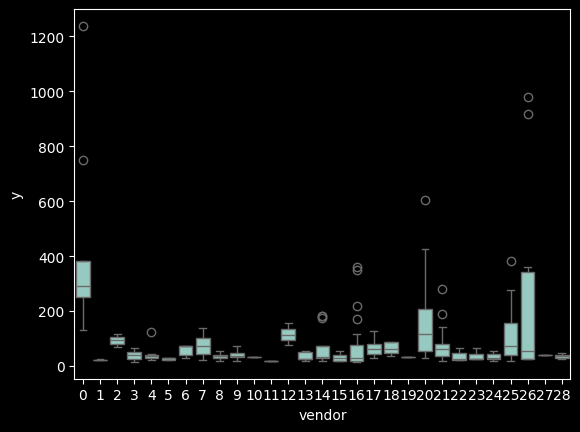

In [8]:
sns.boxplot(x=data.vendor , y=data.y)

<Axes: xlabel='myct', ylabel='y'>

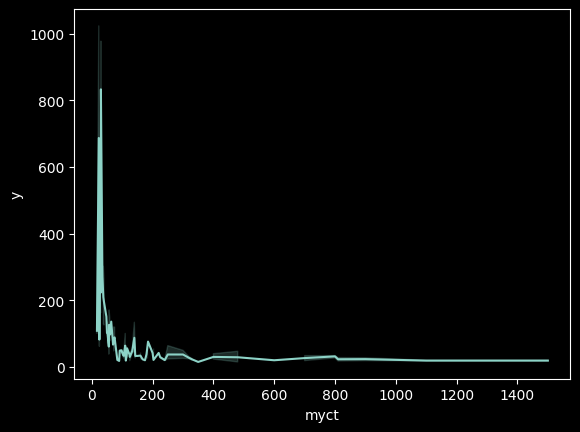

In [9]:
sns.lineplot(x=data.myct , y=data.y)

<Axes: xlabel='mmin', ylabel='y'>

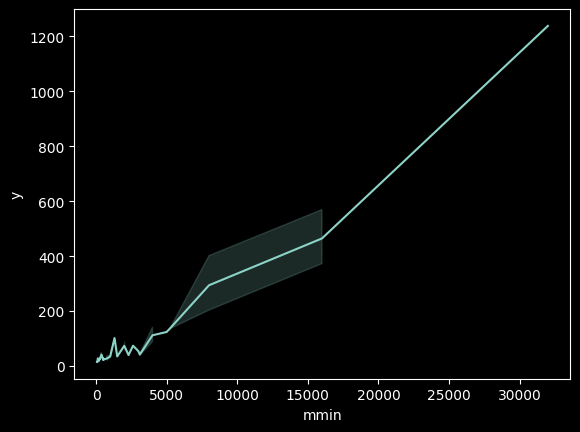

In [10]:
sns.lineplot(x=data.mmin , y=data.y)

<Axes: xlabel='mmax', ylabel='y'>

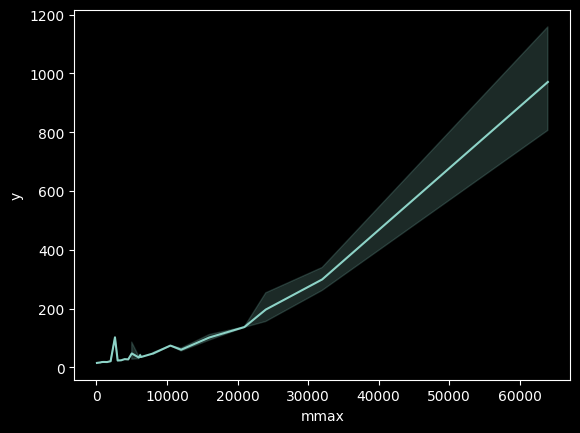

In [11]:
sns.lineplot(x=data.mmax , y=data.y)

<Axes: xlabel='cache', ylabel='y'>

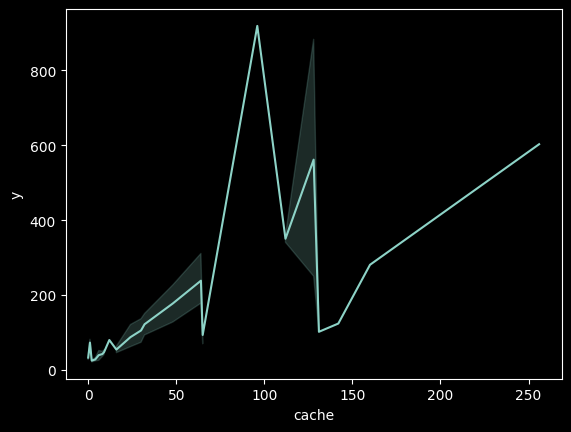

In [12]:
sns.lineplot(x=data.cache , y=data.y)

<Axes: xlabel='chmin', ylabel='y'>

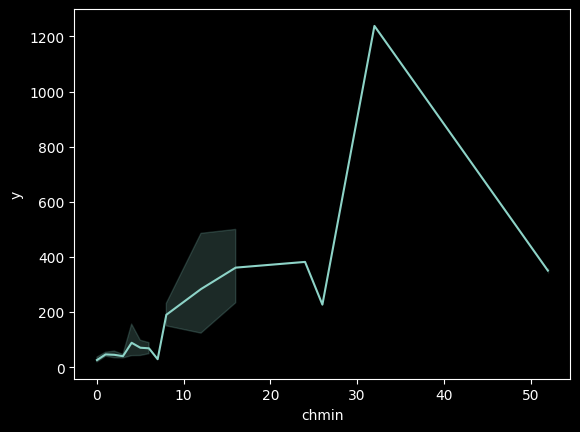

In [13]:
sns.lineplot(x=data.chmin , y=data.y)

In [14]:
data

,vendor,model,myct,mmin,mmax,cache,chmin,chimax,prp,y
0,0,61,29,8000,32000,32,8,32,269,253
1,0,62,29,8000,32000,32,8,32,220,253
2,0,63,29,8000,32000,32,8,32,172,253
3,0,64,29,8000,16000,32,8,16,132,132
4,0,65,26,8000,32000,64,8,32,318,290
...,...,...,...,...,...,...,...,...,...,...
203,26,99,124,1000,8000,0,1,8,42,37
204,26,108,98,1000,8000,32,2,8,46,50
205,27,28,125,2000,8000,0,2,14,52,41
206,28,206,480,512,8000,32,0,0,67,47


<Axes: xlabel='chimax', ylabel='y'>

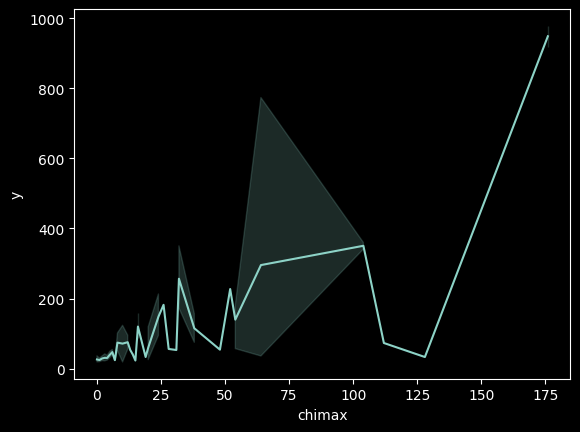

In [15]:
sns.lineplot(x=data.chimax , y=data.y)

<Axes: xlabel='prp', ylabel='y'>

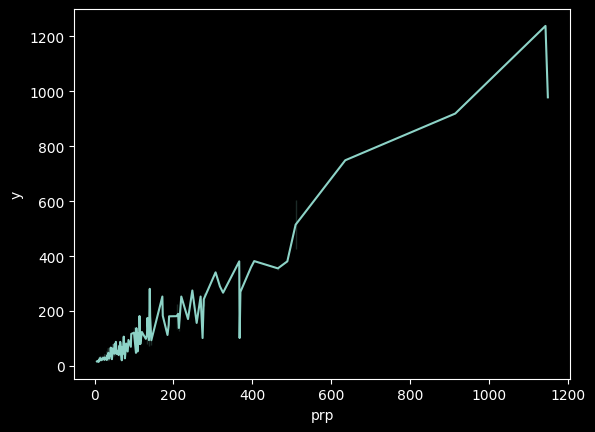

In [16]:
sns.lineplot(x=data.prp , y=data.y)

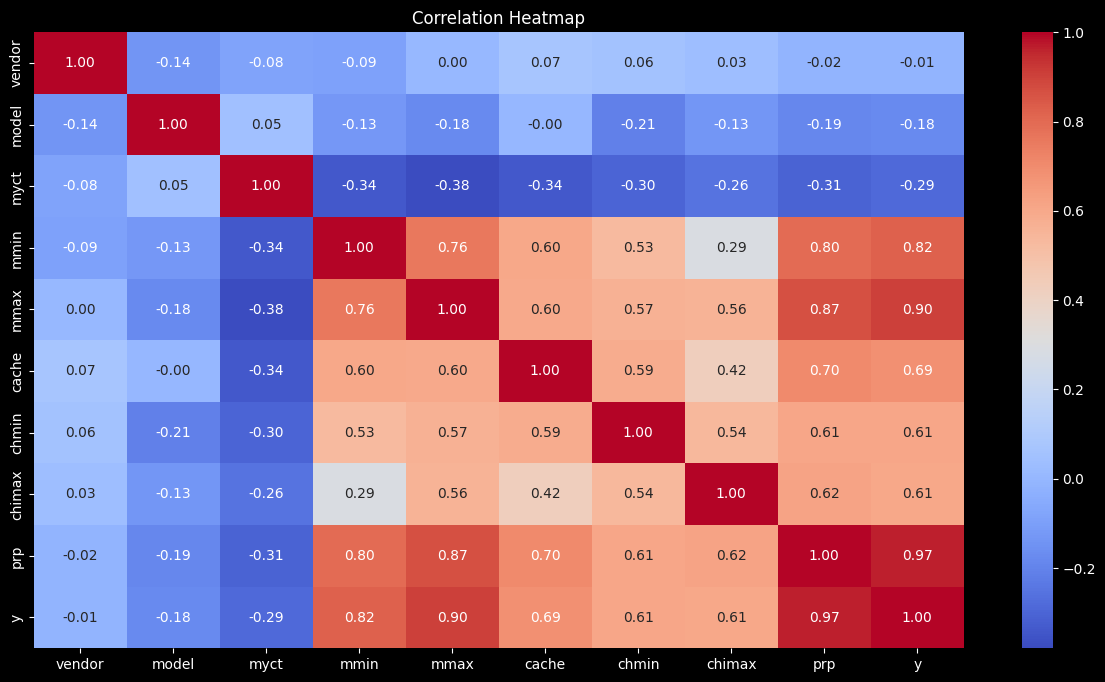

In [17]:
plt.figure(figsize=(15,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [18]:
inputs=data.drop(['myct' , 'y'] , axis=1)
output=data.y

In [19]:
from sklearn.model_selection import train_test_split
x_train  , x_test ,y_train, y_test = train_test_split(inputs , output , test_size=0.2)
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.fit_transform(x_test)

In [20]:
from sklearn.linear_model import LinearRegression
alg=LinearRegression()
alg.fit(x_train,y_train)
pred = alg.predict(x_test)
from sklearn.metrics import r2_score , mean_squared_error
print(r2_score(pred , y_test))
print(mean_squared_error(pred,y_test))


0.9481403964524155
1123.0586269933997


In [21]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures()

x_for_poly = poly.fit_transform(x_train)
reg=LinearRegression()
reg.fit(x_for_poly , y_train)
new_x_test=poly.fit_transform(x_test)
pred_y=reg.predict(new_x_test)



from sklearn.metrics import mean_squared_error , r2_score
print(mean_squared_error(pred_y , y_test))
print(r2_score(pred_y , y_test))

327.6389361097622
0.9844969911364574
